# ⚠️ **Important Disclaimer**

Do **not edit or delete** any of the **Markdown cells** (the ones containing the questions and instructions).

Only write your answers in the **code cells provided below each question**. Try to write each answer in **one code cell** after each question.

# EPA 2021 Vehicle Fuel Economy Dataset Analysis

In this part of the assignment you will explore a comprehensive dataset of 2021 vehicle fuel economy data from the U.S. Environmental Protection Agency (EPA), covering various makes, models, and vehicle configurations.

## Dataset Overview

The dataset includes vehicle specifications, performance metrics, and fuel efficiency data such as:

- `mfr_name`, `division`, `carline` – manufacturer and model information
- `city_mpg`, `hwy_mpg`, `comb_mpg` – fuel efficiency ratings (miles per gallon)
- `engine_displacement`, `no_cylinders` – engine specifications
- `transmission_speed`, `no_gears` – transmission details
- `drive_sys`, `drive_desc` – drivetrain configuration
- `fuel_usage`, `fuel_usage_desc` – fuel type requirements
- `class`, `car_truck` – vehicle classification
- `guzzler` – gas guzzler tax indicator (Y/N)
- `air_aspir_method_desc` – engine aspiration method (naturally aspirated, turbocharged, etc.)


## Q1. Inspect Dataset

Load the packages and the dataset **`epa2021.csv`** into a pandas DataFrame.  
Perform the following tasks:

1. Display the number of **unique values** in the columns `'mfr_name'`, `'class'`, and `'fuel_usage_desc'`.  
2. Print the **number of missing values** for each column in the dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("epa2021.csv")
print(df[['mfr_name','class','fuel_usage_desc']].value_counts())

# count null values
print(f"""
>> Count of null values (Descending) 

{df.isnull().sum().sort_values(ascending=False)}""")

mfr_name        class                                 fuel_usage_desc                        
BMW             Subcompact Cars                       Gasoline (Premium Unleaded Recommended)    39
General Motors  Standard Pick-up Trucks 4WD           Gasoline (Regular Unleaded Recommended)    26
BMW             Midsize Cars                          Gasoline (Premium Unleaded Recommended)    23
Toyota          Midsize Cars                          Gasoline (Regular Unleaded Recommended)    23
Mercedes-Benz   Subcompact Cars                       Gasoline (Premium Unleaded Required)       21
                                                                                                 ..
                Small SUV 2WD                         Gasoline (Premium Unleaded Required)        1
FCA US LLC      Special Purpose Vehicle 2WD           Gasoline (Regular Unleaded Recommended)     1
Toyota          Special Purpose Vehicle, minivan 2WD  Gasoline (Regular Unleaded Recommended)     1
      

In [2]:
df['fuel_usage_desc'].value_counts().sort_index()

fuel_usage_desc
Diesel, low sulfur (500 ppm)                    1
Diesel, ultra low sulfur (15 ppm, maximum)     29
Gasoline (Mid Grade Unleaded Recommended)      12
Gasoline (Premium Unleaded Recommended)       293
Gasoline (Premium Unleaded Required)          262
Gasoline (Regular Unleaded Recommended)       511
Name: count, dtype: int64

## Q2. Handle Columns with High Missing Values

1. Calculate the **percentage of missing values** for each column in the dataset.  
2. Display only the columns that have missing values greater than 0%.  
3. Identify the columns where more than **40% of the data is missing**.  
4. Drop these high-missing-value columns from the DataFrame.
5. Print the shape of the DataFrame after these steps.

In [3]:
# 1. calculate percentage of missing values for each column
null_count = df.isnull().sum().sort_values(ascending=False)
total_rows = len(df)
pct_missing = null_count / total_rows *100

# 2. Print missing values greater than 0%
print(f"{'Column':<20}% Missing")
for col, pct in pct_missing.items():
    if pct > 0:
        print(f"{col:<20} {pct:.2f}%")

# 3. Identify columns with more than 40% missing values
high_missing_col = pct_missing[pct_missing > 40] 
drop_40col = list(pct_missing[pct_missing > 40].index)
print(f"""
>> Missing above 40% values: {drop_40col}
""")

# 4. Drop high missing value columns
df_drop40na = df.drop(columns=drop_40col)

# 5. print dataframe shape
print(f"New dataframe shape: {df_drop40na.shape}")


Column              % Missing
fuel_cell            77.26%
car_truck            45.76%
air_aspir_method     39.62%

>> Missing above 40% values: ['fuel_cell', 'car_truck']

New dataframe shape: (1108, 27)


## Q3. Identify Fuel-Efficient Small Cars

Filter the dataset to select vehicles that meet all of the following criteria:  
- Combined MPG is at least **40**  
- Engine displacement is less than **2.0 liters**  
- Number of cylinders is less than or equal to **4**  

1. Print the total number of such vehicles.  
2. Show their manufacturer name, car line, engine displacement, combined MPG, and number of cylinders. All of them.

In [4]:
# Filter dataframe by criteria
df_sm_fuel_ef = df_sm_fuel_ef = df_drop40na.query(
    "comb_mpg > 40 and engine_displacement < 2 and no_cylinders <= 4"
    ).copy()

# print number of vehicles in criteria
print(f"Number of vehicles in this criteria: {len(df_sm_fuel_ef)}.")

#  Show their manufacturer name, car line, engine displacement, combined MPG, and number of cylinders
cols = ['mfr_name','carline','engine_displacement', 'comb_mpg','no_cylinders']
df_sm_fuel_ef[['mfr_name','carline','engine_displacement', 'comb_mpg','no_cylinders']].sort_values(by=cols)

Number of vehicles in this criteria: 13.


,mfr_name,carline,engine_displacement,comb_mpg,no_cylinders
369,Honda,INSIGHT,1.5,52,4
236,Honda,INSIGHT TOURING,1.5,48,4
374,Hyundai,Elantra Hybrid,1.6,50,4
375,Hyundai,Elantra Hybrid Blue,1.6,54,4
494,Hyundai,Ioniq,1.6,55,4
495,Hyundai,Ioniq Blue,1.6,59,4
534,Kia,Niro,1.6,49,4
535,Kia,Niro FE,1.6,50,4
536,Kia,Niro Touring,1.6,43,4
301,Toyota,COROLLA HYBRID,1.8,52,4


## Q4. Average Engine Displacement by Drive System  

Group the dataset by the `drive_sys` column and calculate the **average engine displacement** for each drive system.  
Sort the results in descending order of average engine displacement and display the top 5 results.

In [5]:
# avg engine displacement by drive system
top5_avg_eng = df_drop40na.groupby('drive_sys', dropna=False)['engine_displacement'].mean().reset_index().sort_values(by='engine_displacement', ascending=False).head(5)
print(top5_avg_eng)

  drive_sys  engine_displacement
0         4             3.776111
4         R             3.751812
3         P             3.440000
1         A             3.023464
2         F             2.125758


## Q5. Create Derived Fuel Economy Metrics  

1. Create a new column `fuel_economy_score` as a weighted average of city and highway MPG, where city MPG contributes **30%** and highway MPG contributes **70%**.  
2. Create another column `mpg_zscore` that standardizes the combined MPG (`comb_mpg`) by subtracting the mean and dividing by the standard deviation.  
3. Display the first 10 rows of the DataFrame showing the following columns:  
   - `mfr_name`, `carline`, `city_mpg`, `hwy_mpg`, `comb_mpg`, `fuel_economy_score`, and `mpg_zscore`.

In [6]:
# 5.1. Create a new weighted column `fuel_economy_score`
df_drop40na['fuel_economy_score'] = df_drop40na['city_mpg']* 0.3 + df_drop40na['hwy_mpg'] * 0.7

# 2. Create another column `mpg_zscore` that standardizes the combined MPG (`comb_mpg`) by subtracting the mean and dividing by the standard deviation.  
df_drop40na['mpg_zscore'] = (df_drop40na['comb_mpg'] - df_drop40na['comb_mpg'].mean()) / df_drop40na['comb_mpg'].std()

# 3. Display the first 10 rows of the DataFrame
df_drop40na[['mfr_name', 'carline', 'city_mpg', 'hwy_mpg', 'comb_mpg', 'fuel_economy_score', 'mpg_zscore']].head(10)

,mfr_name,carline,city_mpg,hwy_mpg,comb_mpg,fuel_economy_score,mpg_zscore
0,Honda,NSX,21,22,21,21.7,-0.354518
1,aston martin,Vantage Manual,14,21,17,18.9,-0.975065
2,aston martin,Vantage V8,18,24,20,22.2,-0.509655
3,Volkswagen Group of,R8,13,20,16,17.9,-1.130201
4,Volkswagen Group of,R8 2WD,14,23,17,20.3,-0.975065
5,Volkswagen Group of,R8 Spyder,13,20,16,17.9,-1.130201
6,Volkswagen Group of,R8 Spyder 2WD,14,23,17,20.3,-0.975065
7,Volkswagen Group of,TT Roadster quattro,23,31,26,28.6,0.421165
8,BMW,Z4 M40i,22,30,25,27.6,0.266029
9,BMW,Z4 sDrive30i,25,32,28,29.9,0.731438


## Q6. Transmission Type Analysis  

Perform an analysis of vehicle transmissions with respect to fuel efficiency:  

1. Group the dataset by the `transmission` column.  
2. For each transmission type, calculate the following aggregations of `comb_mpg`:  
   - **mean**  
   - **standard deviation**  
   - **count** of vehicles  
3. Round all results to two decimal places.  
5. Do not forget to reset the index so that `transmission` appears as a regular column in the resulting DataFrame. Your final columns (excluding the index) should be exactly as follows:  
   - `transmission`,  `Avg_MPG`, `Std_MPG`, `Count`  
6. Sort the results by the average MPG (**Avg_MPG**) in descending order.  
7. Display the resulting table.
8. Save the final DataFrame to a CSV file named **`transmission_analysis.csv`**.

In [7]:
# 1 > 4 group by transmission and aggregate comb_mpg, reset index and nome columns
transm_mpg = df_drop40na.groupby('transmission', dropna=False)['comb_mpg'].agg(['mean', 'std', 'count']).round(2).reset_index()
transm_mpg.columns = ['transmission', 'Avg_MPG', 'Std_MPG', 'Count']

# 5 sort results by Avg_MPG
transm_mpg = transm_mpg.sort_values(by='Avg_MPG', ascending=False)

# 6 Display resulting table
print(transm_mpg)

# 7 Save df to 
transm_mpg.to_csv("transmission_analysis.csv", index=False)


  transmission  Avg_MPG  Std_MPG  Count
3          CVT    35.58     7.61     45
6          SCV    31.59     5.86     73
2          AMS    24.12     9.66    115
4            M    24.08     5.43     85
5           SA    22.42     4.15    461
1           AM    21.69     5.65     32
0            A    20.35     3.66    297


## Q7. Distribution of Fuel Economy Score  

Create a histogram to visualize the distribution of the fuel economy score that you computed above.  
Use 30 bins and overlay a kernel density estimate (KDE) curve.  
Label the axes appropriately and add a descriptive title to the plot. 

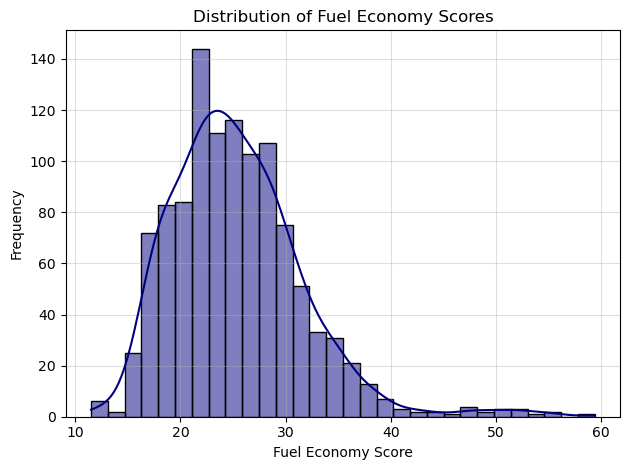

In [8]:
# ANSWER HERE

sns.histplot(df_drop40na['fuel_economy_score'], kde=True, bins=30, color='navy', edgecolor='black')
plt.title("Distribution of Fuel Economy Scores")
plt.xlabel("Fuel Economy Score")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Q8. Average MPG by Engine Displacement Range  

In this task, you will group vehicles into **engine displacement ranges**.  

1. Create a new column `displacement_bin` that categorizes vehicles into the following ranges based on their engine displacement (the category names should be simple Strings):  
   - `0-2L`  
   - `2-4L`  
   - `4-6L`  
   - `6L+`  
2. Group the dataset by this new `displacement_bin` column and calculate the **average combined MPG** for each range.  
3. Create a bar chart showing the average combined MPG per displacement range.  
   - Label the axes appropriately.  
   - Add a descriptive title.

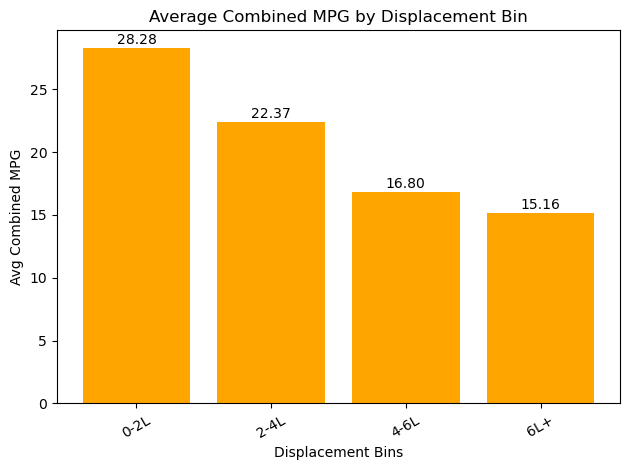

In [9]:
# 1) Create displacement_bin
bins = [0, 2, 4, 6, 999]
labels = ["0-2L","2-4L","4-6L","6L+"]
df_drop40na["displacement_bin"] = pd.cut(pd.to_numeric(df_drop40na['engine_displacement'], errors="coerce"),
                                bins=bins, labels=labels, right=True, include_lowest=True)

# 2) Group and compute average combined MPG
df_displacement = (df_drop40na.dropna(subset=["displacement_bin"])
             .groupby("displacement_bin", observed=True)['comb_mpg']
             .mean()
             .rename("avg_combined_mpg")
             .reset_index())

# plot bar chart of results
bars = plt.bar(df_displacement['displacement_bin'],df_displacement['avg_combined_mpg'], color = 'orange')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom')
plt.title("Average Combined MPG by Displacement Bin")
plt.xlabel("Displacement Bins")
plt.ylabel("Avg Combined MPG")
plt.xticks(rotation=30, fontsize=10)
plt.tight_layout()
plt.show()

## Q9. Vehicle Performance Analysis  

Create a scatter plot showing the relationship between **engine displacement** and **combined MPG**.  

- The x-axis represents **engine displacement (Liters)**.  
- The y-axis represents **combined MPG**.
- Color the points by **drive system** (`drive_sys`).  
- Scale point sizes by **number of cylinders** (`no_cylinders`).  
- Add dashed reference lines for the average engine displacement and average combined MPG. Include labels for both lines in the legend.  
- Label the axes and add a descriptive title.  

Also add:
- A legend showing the categories for drive system and cylinders.  
- Gridlines for better readability.

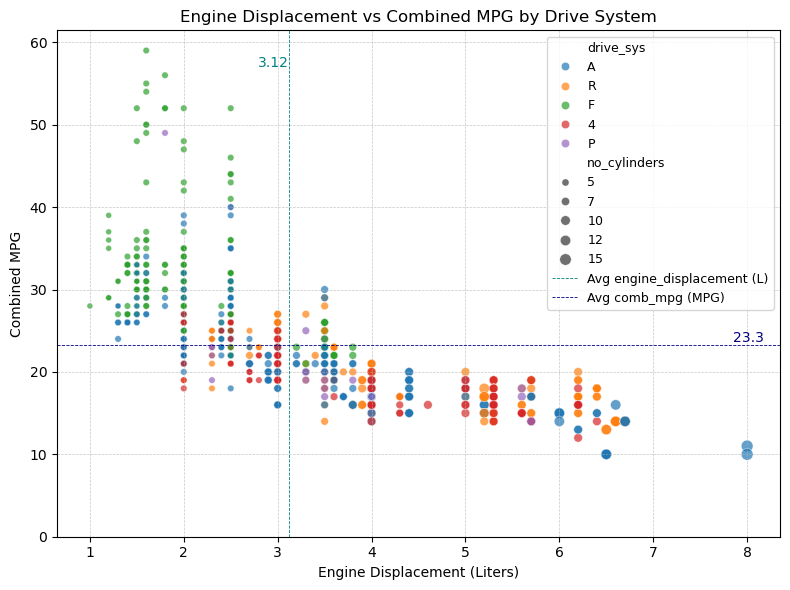

In [10]:
# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_drop40na,
    x="engine_displacement",
    y="comb_mpg",
    hue="drive_sys",
    size='no_cylinders',
    alpha=0.7,
)

# Compute averages
avg_x = df_drop40na['engine_displacement'].mean()
avg_y = df_drop40na['comb_mpg'].mean()

# Add vertical dashed line (with label)
plt.axvline(avg_x, color="teal", linestyle="--", linewidth=0.6, label=f"Avg engine_displacement (L)")
plt.text(avg_x, plt.ylim()[1]*0.95, f"{avg_x:.2f}", color="teal", ha="right", va="top")

# Add horizontal dashed line (with label)
plt.axhline(avg_y, color="navy", linestyle="--", linewidth=0.6, label=f"Avg comb_mpg (MPG)")
plt.text(plt.xlim()[1]*0.98, avg_y, f"{avg_y:.1f}", color="navy", ha="right", va="bottom")

# Labels
plt.xlabel("Engine Displacement (Liters)")
plt.ylabel("Combined MPG")
plt.title("Engine Displacement vs Combined MPG by Drive System")
plt.legend(fontsize=9)

# Grid and layout
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.ylim(bottom=0)
plt.tight_layout()

plt.show()

## Q10. Recreate the Heatmap with Pivot Table 

Your task is to reproduce the following figure as closely as possible.  

**Important:** You **must** use a **pivot table** to solve this problem.

Here are a few helpful hints:  
- The plot was created using **Seaborn's `heatmap()`** function.  
- The color map used is **YlGnBu**.  

Start with a basic heatmap, then refine it by adding/adjusting:  
- annotations  
- ticks  
- labels  
- borders  
- title and axis labels  

**Save your final plot as a PDF file named:**  
`city_mpg_heatmap.pdf`

### Reference Figure

![Reference Heatmap](reference_heatmap.png)

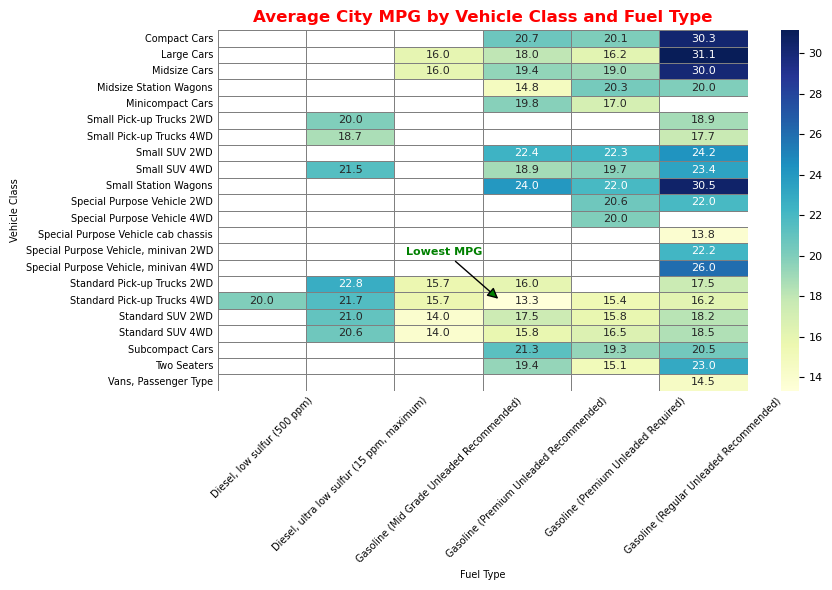

In [43]:
# Create Pivot Table
pivot_table = df_drop40na.pivot_table(
    index="class",
    columns="fuel_usage_desc",
    values="city_mpg",
    aggfunc="mean"
)

# Plot Heatmap
plt.figure(figsize=(9, 6))
ax = sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="gray",
    annot_kws={"size": 8}
    )

# Colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

# Find minimum cell (row label, col label) & value
min_idx = pivot_table.stack().idxmin()
row_label, col_label = min_idx
min_val = pivot_table.loc[row_label, col_label]

# Convert labels to heatmap coordinates (cell centers)
row_pos = list(pivot_table.index).index(row_label)
col_pos = list(pivot_table.columns).index(col_label)
x = col_pos + 1
y = row_pos - 1.5

# Choose a text position offset
x_text = x - 1
y_text = y - 0.8

# Annotate with an arrow pointing to the min cell
ax.annotate(
    f"Lowest MPG",
    xy=((x-0.8), (y+2)),
    xytext=(x_text, y_text),
    arrowprops=dict(
        arrowstyle="-|>,head_length=0.8,head_width=0.4", 
        facecolor="green", 
        edgecolor="black", 
        lw=1),
    fontsize=8, fontweight='bold', color='green',
    ha="right",
    zorder=10
)

# Labels & ticks
ax.set_title("Average City MPG by Vehicle Class and Fuel Type", color='red', fontweight='bold', fontsize=12)
ax.set_xlabel("Fuel Type", fontsize=7)
ax.set_ylabel("Vehicle Class", fontsize=7)
ax.tick_params(axis="x", labelrotation=45, labelsize=7)
ax.tick_params(axis="y", labelsize=7)
plt.tick_params(axis="both", which="both", length=0)
plt.tight_layout()
plt.savefig("city_mpg_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()
